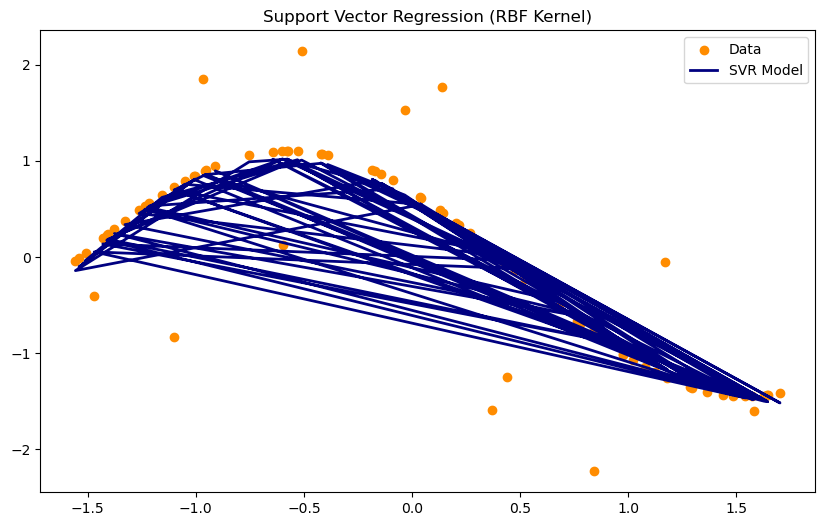

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

# 1. THE DATA (Simulating a Stock Price Trend)
# We create a curved relationships (sine wave) + noise
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel()
# Add noise to every 5th point to test robustness
y[::5] += 3 * (0.5 - np.random.rand(20))

# 2. THE SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. SCALING (Mandatory for SVR)
# SVR is sensitive to the scale of the data. 
sc_X = StandardScaler()
sc_y = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# 4. TRAINING (The Regression Tube)
# kernel='rbf': Allows us to fit curves
# C=100: We are strict about points outside the tube
# epsilon=0.1: The width of our "safety tube" where errors are ignored
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled, y_train_scaled, color='darkorange', label='Data')
plt.plot(X_train_scaled, svr_model.predict(X_train_scaled), color='navy', lw=2, label='SVR Model')
plt.title('Support Vector Regression (RBF Kernel)')
plt.legend()
plt.show()